In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os
from pathlib import Path

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

from scipy.stats import linregress
# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

In [5]:
work_dir = Path("..")

In [6]:
# List of molecules and lengths
seq_lengths = {'B_fragilis_chr': 5205140,
                'B_fragilis_p1': 36560,
                'P_nigrescens_chr1': 567798,
                'P_nigrescens_chr2': 2105254,
                'P_nigrescens_p1': 2630,
                'P_nigrescens_p2': 2697,
                'P_nigrescens_p3': 2697,
                'P_nigrescens_p4': 3815,
                'E_faecium_chr': 2529607,
                'E_faecium_p1': 142622,
                'S_flexneri_chr': 4659463,
                'S_flexneri_p1': 113130,
                'S_flexneri_p2': 165702,
                'S_flexneri_p3': 4110,
                'S_flexneri_p4': 3179,
                'C_aerofaciens_chr': 2428218,
                'C_aerofaciens_p1': 23044,
                'C_aerofaciens_p2': 4066
               }

In [18]:
# Load a Hi-C map at a 1kb resolution from a cooler file.
resolution = 100# note this might be slightly slow on a laptop
                  # and could be lowered to 10kb for increased speed
cooler_path = work_dir / "data/synthetic_community/Hicexplorer/all_resolutions.mcool"
clr = cooler.Cooler(f"{cooler_path}::/resolutions/{resolution}")

In [19]:
# Calculate average contact frequencies
cvd_smooth_agg = cooltools.expected_cis(
    clr=clr,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus
)
# Add species and seq_type columns to cvd_smooth_agg
cvd_smooth_agg['species'] = cvd_smooth_agg['region1'].str.rsplit('_', n=1).str[0]
cvd_smooth_agg['seq_type'] = cvd_smooth_agg['region1'].str.rsplit('_', n=1).str[1].map(
    lambda x: 'plasmid' if x.startswith('p') else 'chromosome'
)
display(cvd_smooth_agg.head(4))

INFO:root:creating a Pool of 80 workers


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg,species,seq_type
0,B_fragilis_chr,B_fragilis_chr,0,0,NaN,52052,52052,NaN,NaN,NaN,NaN,NaN,NaN,B_fragilis,chromosome
1,B_fragilis_chr,B_fragilis_chr,1,100,0.028845,52051,52051,NaN,NaN,NaN,NaN,0.035968,0.028845,B_fragilis,chromosome
2,B_fragilis_chr,B_fragilis_chr,2,200,2.544017,52050,52050,90810.632013,175559.876523,1.744681,3.372908,3.185550,2.544017,B_fragilis,chromosome
3,B_fragilis_chr,B_fragilis_chr,3,300,1.914034,52049,52049,61045.495697,131461.446686,1.172847,2.525725,2.450438,1.914034,B_fragilis,chromosome


In [20]:
# Function to obtain slope reference lines
def make_ref_line(slope, x0, y0, xlim):
    x_vals = np.array(xlim)
    y_vals = y0 * (x_vals / x0) ** slope
    return x_vals, y_vals

In [21]:
# Define reference lines for slopes -1 and -0.5
xlim_ref = [500, 100000]

x_ref1, y_ref1 = make_ref_line(slope=-1,   x0=200, y0=1,       xlim=xlim_ref)
x_ref2, y_ref2 = make_ref_line(slope=-0.5, x0=1000, y0=1 * 1.5, xlim=xlim_ref)

In [22]:
# Remove sequences with no contacts
cvd_smooth_agg = cvd_smooth_agg[
    ~(
        cvd_smooth_agg["species"].isin(["B_fragilis", "P_nigrescens"]) &
        (cvd_smooth_agg["seq_type"] == "plasmid")
    )
]
cvd_smooth_agg 

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg,species,seq_type
0,B_fragilis_chr,B_fragilis_chr,0,0,NaN,52052,52052,NaN,NaN,NaN,NaN,NaN,NaN,B_fragilis,chromosome
1,B_fragilis_chr,B_fragilis_chr,1,100,0.028845,52051,52051,NaN,NaN,NaN,NaN,0.035968,0.028845,B_fragilis,chromosome
2,B_fragilis_chr,B_fragilis_chr,2,200,2.544017,52050,52050,90810.632013,175559.876523,1.744681,3.372908,3.185550,2.544017,B_fragilis,chromosome
3,B_fragilis_chr,B_fragilis_chr,3,300,1.914034,52049,52049,61045.495697,131461.446686,1.172847,2.525725,2.450438,1.914034,B_fragilis,chromosome
4,B_fragilis_chr,B_fragilis_chr,4,400,1.526929,52048,52048,48451.261992,105389.456297,0.930896,2.024851,1.971932,1.526929,B_fragilis,chromosome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180002,C_aerofaciens_p2,C_aerofaciens_p2,36,3600,0.363183,5,5,0.006633,1.627922,0.001327,0.325584,0.371658,0.363183,C_aerofaciens,plasmid
180003,C_aerofaciens_p2,C_aerofaciens_p2,37,3700,0.355532,4,4,0.007828,1.715163,0.001957,0.428791,0.392560,0.355532,C_aerofaciens,plasmid
180004,C_aerofaciens_p2,C_aerofaciens_p2,38,3800,0.348237,3,3,0.013561,2.760886,0.004520,0.920295,0.414374,0.348237,C_aerofaciens,plasmid
180005,C_aerofaciens_p2,C_aerofaciens_p2,39,3900,0.341274,2,2,0.049120,7.722891,0.024560,3.861445,0.437007,0.341274,C_aerofaciens,plasmid


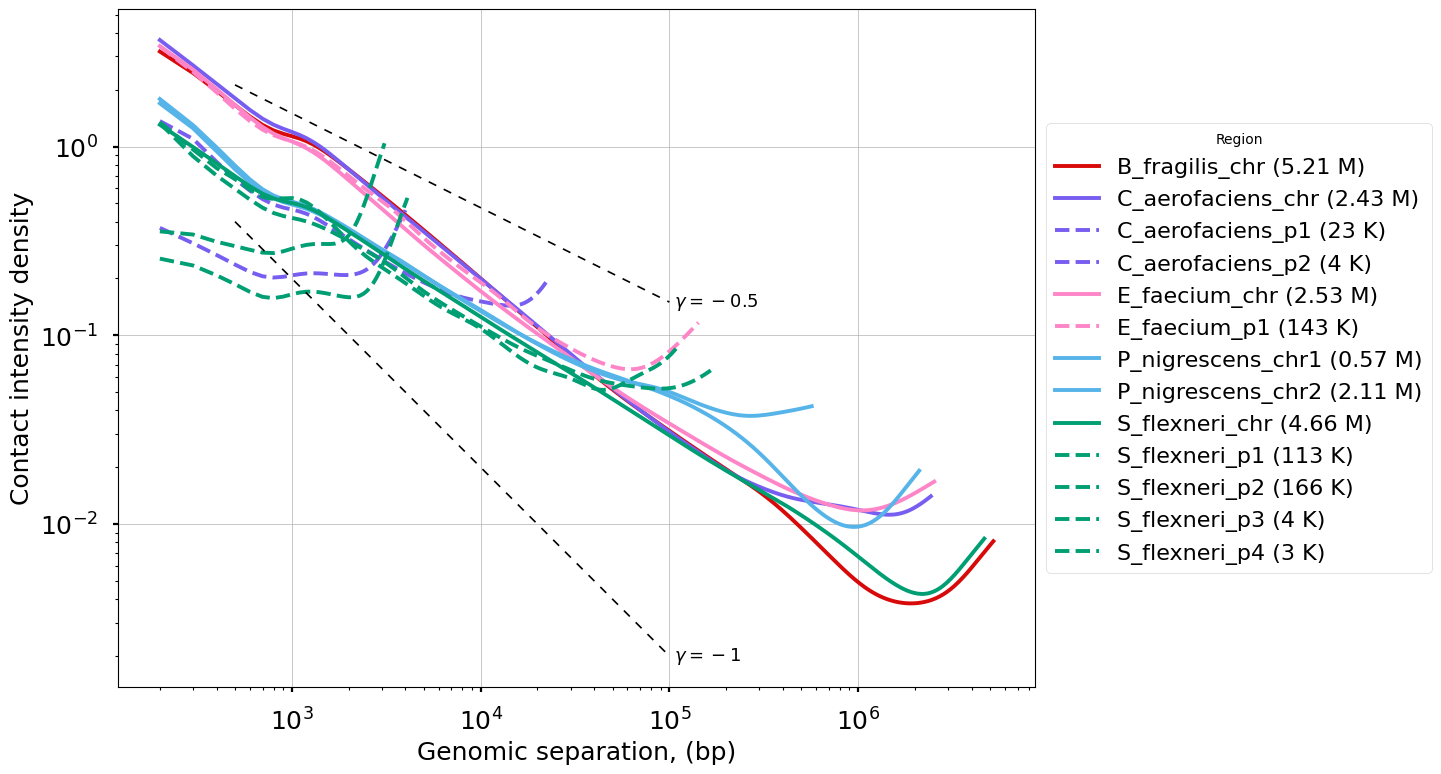

In [23]:
cvd_smooth_agg['balanced.avg.smoothed'].loc[cvd_smooth_agg['dist'] < 2] = np.nan

# Build color map (reuse the same one from before for consistency)
species_list = cvd_smooth_agg['species'].unique()
palette = ["#D70909", '#56B4E9',"#FE85C8", '#009E73', '#785EF0', '#0072B2', '#D55E00']
species_colors = {sp: palette[i % len(palette)] for i, sp in enumerate(species_list)}

# Plot scailing curves with reference slopes
f, ax = plt.subplots(1,1)

for region in np.unique(cvd_smooth_agg['region1']):
    species = cvd_smooth_agg.loc[cvd_smooth_agg['region1'] == region, 'species'].iloc[0]
    seq_type = cvd_smooth_agg.loc[cvd_smooth_agg['region1'] == region, 'seq_type'].iloc[0]
    seq_length = seq_lengths[region]
    if seq_type == "plasmid":
        length_str = f"{seq_length/1e3:.0f} K"
    else:  # chromosome
        length_str = f"{seq_length/1e6:.2f} M"
    ax.loglog(
        cvd_smooth_agg['dist_bp'].loc[cvd_smooth_agg['region1']==region],
        cvd_smooth_agg['balanced.avg.smoothed'].loc[cvd_smooth_agg['region1']==region],
        color=species_colors[species],
        linestyle='--' if seq_type == 'plasmid' else '-',
        label=f"{region} ({length_str})"
    )

# reference lines
ax.loglog(x_ref1, y_ref1, color='black', linestyle=(0, (5, 5)), linewidth=1.2)
ax.loglog(x_ref2, y_ref2, color='black', linestyle=(0, (5, 5)), linewidth=1.2)
ax.text(x_ref1[-1], y_ref1[-1], r' $\gamma=-1$', fontsize=13, va='center')
ax.text(x_ref2[-1], y_ref2[-1], r' $\gamma=-0.5$', fontsize=13, va='center')

ax.set(
    xlabel='Genomic separation, (bp)',
    ylabel='Contact intensity density')
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_aspect(1.0)
ax.grid(lw=0.5)
ax.legend(
    title='Region',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    borderaxespad=0.5
)